Zadanie 16

Training with batch size: 16
Training with batch size: 32
Training with batch size: 64
Training with batch size: 128
Training with batch size: 256
Training with batch size: auto


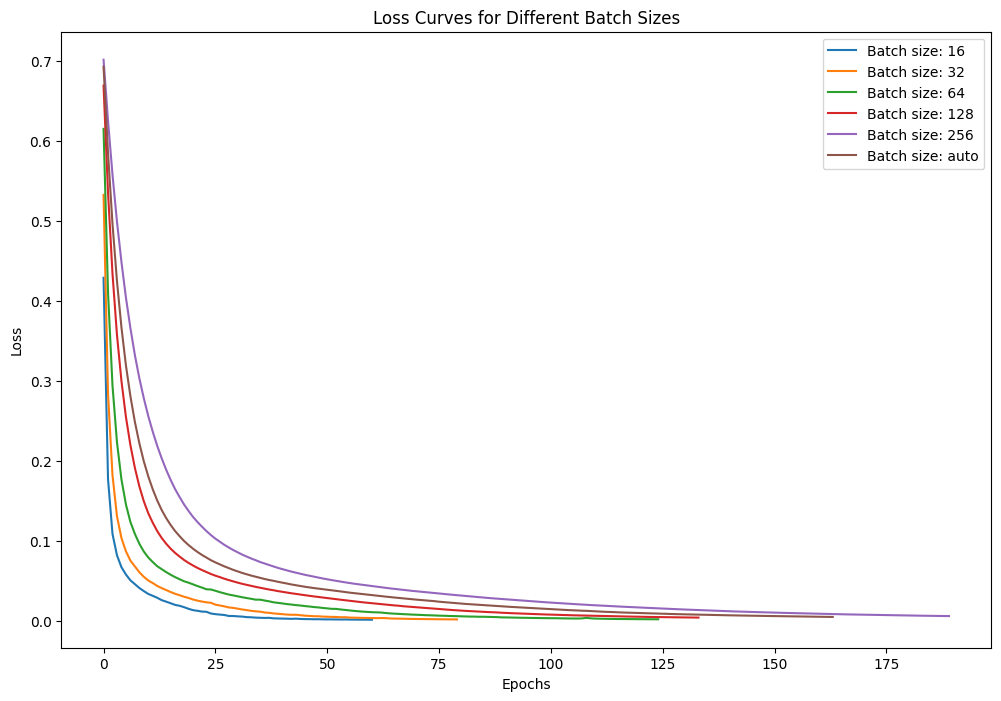

Batch size: 16, Accuracy: 0.9649, Training time: 0.41 seconds
Batch size: 32, Accuracy: 0.9737, Training time: 0.29 seconds
Batch size: 64, Accuracy: 0.9649, Training time: 0.27 seconds
Batch size: 128, Accuracy: 0.9649, Training time: 0.20 seconds
Batch size: 256, Accuracy: 0.9649, Training time: 0.23 seconds
Batch size: auto, Accuracy: 0.9649, Training time: 0.20 seconds


In [ ]:
import time
import matplotlib.pyplot as plt
import numpy as np
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score

data = load_breast_cancer() 
X = data.data
y = data.target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

batch_sizes = [16, 32, 64, 128, 256, 'auto']

results = []

for batch_size in batch_sizes:  
    print(f'Training with batch size: {batch_size}')
    mlp = MLPClassifier(hidden_layer_sizes=(64, 32), solver='adam', max_iter=300, batch_size=batch_size, random_state=42)
    start_time = time.time()
    mlp.fit(X_train_scaled, y_train)
    end_time = time.time()
    training_time = end_time - start_time
    y_pred = mlp.predict(X_test_scaled)
    accuracy = accuracy_score(y_test, y_pred)
    loss_curve = mlp.loss_curve_
    results.append((batch_size, accuracy, training_time, loss_curve))

plt.figure(figsize=(12, 8))
for batch_size, accuracy, training_time, loss_curve in results:
    plt.plot(loss_curve, label=f'Batch size: {batch_size}') 
plt.title('Loss Curves for Different Batch Sizes')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()  

for batch_size, accuracy, training_time, loss_curve in results:
    print(f'Batch size: {batch_size}, Accuracy: {accuracy:.4f}, Training time: {training_time:.2f} seconds')

        


Zadanie 19

In [3]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier 

param_grid = {
    'hidden_layer_sizes': [(32,), (64,), (32, 16), (64, 32)],
    'activation': ['relu', 'tanh'],
    'learning_rate_init': [0.001, 0.01],
    'alpha': [0.0001, 0.001, 0.01]
}
mlp = MLPClassifier(solver='adam', max_iter=300, random_state=42)
grid_search = GridSearchCV(estimator=mlp, param_grid=param_grid, cv=5, scoring='accuracy', n_jobs=-1)
grid_search.fit(X_train_scaled, y_train)
best_params = grid_search.best_params_
best_score = grid_search.best_score_
print(f'Best parameters: {best_params}')
print(f'Best cross-validation accuracy: {best_score:.4f}')


default_mlp = MLPClassifier(solver='adam', max_iter=300, random_state=42)
default_mlp.fit(X_train_scaled, y_train)
default_pred = default_mlp.predict(X_test_scaled)
default_accuracy = accuracy_score(y_test, default_pred)
print(f'Default MLP accuracy: {default_accuracy:.4f}')

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train_scaled, y_train)
rf_pred = rf.predict(X_test_scaled)
rf_accuracy = accuracy_score(y_test, rf_pred)
print(f'Random Forest accuracy: {rf_accuracy:.4f}')


Best parameters: {'activation': 'relu', 'alpha': 0.0001, 'hidden_layer_sizes': (32, 16), 'learning_rate_init': 0.001}
Best cross-validation accuracy: 0.9846
Default MLP accuracy: 0.9649
Random Forest accuracy: 0.9561
